In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

df = pd.read_csv('spain_energy_market.csv')
df.head(10)

,datetime,id,name,geoid,geoname,value
0,2014-01-01 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,25.280833
1,2014-01-02 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,39.924167
2,2014-01-03 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.992083
3,2014-01-04 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,4.091667
4,2014-01-05 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,13.587500
5,2014-01-06 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,47.885417
6,2014-01-07 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,41.207500
7,2014-01-08 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,49.022083
8,2014-01-09 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,56.202917
9,2014-01-10 23:00:00,600,Precio mercado SPOT Diario ESP,3.0,España,50.277083


In [15]:
df['name'].value_counts(dropna=False)

name
NaN                                                                       5478
Precio mercado SPOT Diario ESP                                            1826
Precio mercado SPOT Diario FRA                                            1826
Precio mercado SPOT Diario POR                                            1826
Energía asignada en Mercado SPOT Diario España                            1826
Energía asignada en Mercado SPOT Diario Francia                           1826
Generación programada PBF Gas Natural Cogeneración                        1826
Generación programada PBF UGH + no UGH                                    1826
Generación programada PBF Solar fotovoltaica                              1826
Demanda real                                                              1825
Demanda programada PBF total                                              1825
Generación programada PBF total                                           1825
Generación programada PBF Eólica               

In [16]:
precio_es = df[df['name'] == 'Precio mercado SPOT Diario ESP'][['datetime', 'value']]
precio_es = precio_es.rename(columns={'value': 'precio_eur_mwh'})

demanda_es = df[df['name'] == 'Demanda real'][['datetime', 'value']]
demanda_es = demanda_es.rename(columns={'value': 'demanda_mwh'})

print(precio_es.shape)
print(demanda_es.shape)
precio_es.head()

(1826, 2)
(1825, 2)


,datetime,precio_eur_mwh
0,2014-01-01 23:00:00,25.280833
1,2014-01-02 23:00:00,39.924167
2,2014-01-03 23:00:00,4.992083
3,2014-01-04 23:00:00,4.091667
4,2014-01-05 23:00:00,13.587500


In [17]:
serie_es = pd.merge(precio_es, demanda_es, on='datetime', how='outer')
serie_es = serie_es.sort_values('datetime')

print(serie_es.shape)
print(serie_es.isnull().sum())
serie_es.head()

(1826, 3)
datetime          0
precio_eur_mwh    0
demanda_mwh       1
dtype: int64


,datetime,precio_eur_mwh,demanda_mwh
0,2014-01-01 23:00:00,25.280833,28191.597222
1,2014-01-02 23:00:00,39.924167,28465.180556
2,2014-01-03 23:00:00,4.992083,26860.493056
3,2014-01-04 23:00:00,4.091667,25333.597222
4,2014-01-05 23:00:00,13.587500,23905.541667


In [18]:
serie_es[serie_es['demanda_mwh'].isnull()]

,datetime,precio_eur_mwh,demanda_mwh
1825,2018-12-31 23:00:00,63.454583,NaN


In [19]:
serie_es['datetime'] = pd.to_datetime(serie_es['datetime'])
serie_es = serie_es.set_index('datetime')
serie_es['demanda_mwh'] = serie_es['demanda_mwh'].interpolate(method='time')

print(serie_es.isnull().sum())
serie_es.tail()

precio_eur_mwh    0
demanda_mwh       0
dtype: int64


,precio_eur_mwh,demanda_mwh
datetime,,
2018-12-27 23:00:00,63.785417,28624.194444
2018-12-28 23:00:00,57.048333,26632.840278
2018-12-29 23:00:00,58.493750,25255.055556
2018-12-30 23:00:00,61.795000,25908.576389
2018-12-31 23:00:00,63.454583,25908.576389


In [20]:
serie_es.sort_values('precio_eur_mwh').head(10)

,precio_eur_mwh,demanda_mwh
datetime,,
2014-02-08 23:00:00,0.477917,26391.076389
2014-03-01 23:00:00,0.778750,25153.986111
2014-02-07 23:00:00,1.100000,28287.645833
2014-03-02 23:00:00,1.268750,30109.993056
2014-02-28 23:00:00,2.280417,28182.451389
2014-03-03 23:00:00,2.840833,31147.451389
2014-02-13 23:00:00,3.124583,30560.840278
2014-02-09 23:00:00,3.183333,31329.951389
2014-02-06 23:00:00,3.195000,31381.583333


In [21]:
serie_es['dia_semana'] = serie_es.index.day_name()
serie_es['es_finde'] = serie_es.index.dayofweek >= 5

serie_es.head()

,precio_eur_mwh,demanda_mwh,dia_semana,es_finde
datetime,,,,
2014-01-01 23:00:00,25.280833,28191.597222,Wednesday,False
2014-01-02 23:00:00,39.924167,28465.180556,Thursday,False
2014-01-03 23:00:00,4.992083,26860.493056,Friday,False
2014-01-04 23:00:00,4.091667,25333.597222,Saturday,True
2014-01-05 23:00:00,13.587500,23905.541667,Sunday,True


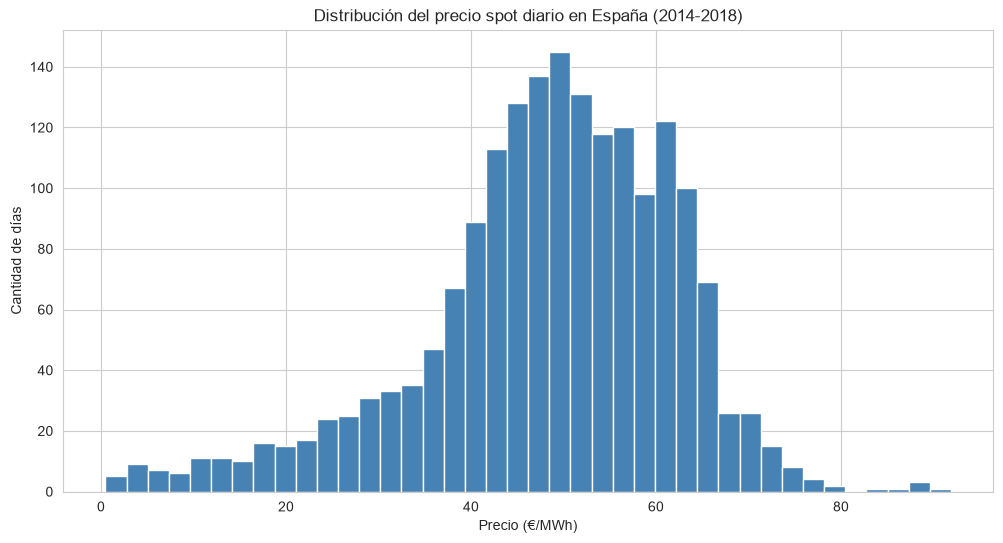

In [22]:
plt.hist(serie_es['precio_eur_mwh'], bins=40, color='steelblue', edgecolor='white')
plt.title('Distribución del precio spot diario en España (2014-2018)')
plt.xlabel('Precio (€/MWh)')
plt.ylabel('Cantidad de días')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución completa de precios diarios del mercado eléctrico español.
Hallazgo: el precio típico se ubica entre $40-65/MWh, con una cola hacia precios bajos (asociada al período de sobreoferta de inicios de 2014) más marcada que la cola hacia precios altos.
Recomendación: al reportar "el precio típico" de la electricidad en España, usar el rango central ($40-65) como referencia, aclarando que hubo un período específico (inicios de 2014) que empuja la distribución hacia abajo — no representativo del comportamiento habitual del mercado en el resto del período.

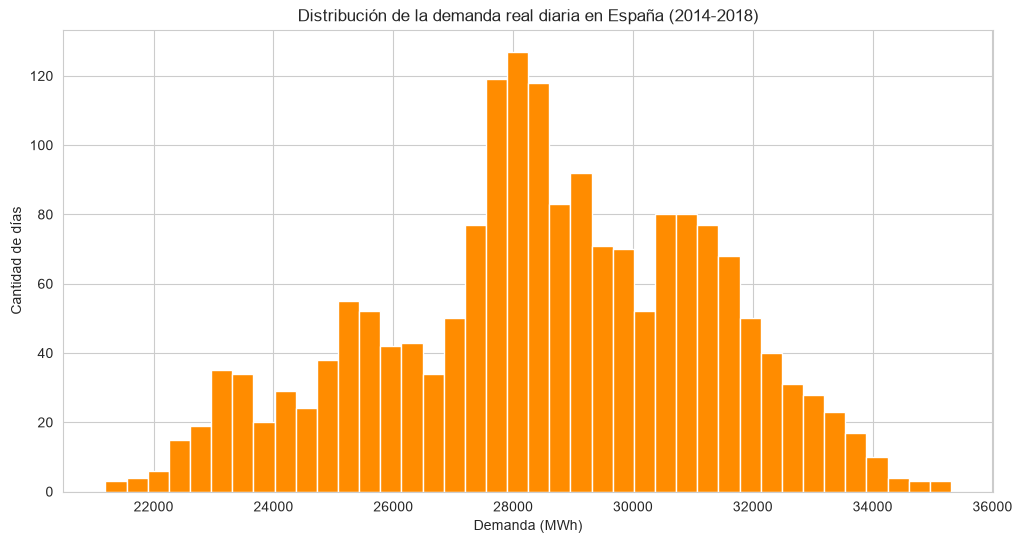

In [23]:
plt.hist(serie_es['demanda_mwh'], bins=40, color='darkorange', edgecolor='white')
plt.title('Distribución de la demanda real diaria en España (2014-2018)')
plt.xlabel('Demanda (MWh)')
plt.ylabel('Cantidad de días')
plt.show()

Mini-reporte de este gráfico:

Situación: graficamos la distribución de la demanda eléctrica diaria en España.
Hallazgo: distribución razonablemente simétrica centrada en ~28,000 MWh, sin los sesgos marcados que vimos en el precio — sugiere que la demanda es más estable/predecible que el precio.
Recomendación: esto plantea una pregunta para el análisis complejo: si la demanda es estable pero el precio no, ¿qué tan fuerte es realmente la relación entre ambas? Vale la pena cuantificarlo con una correlación, en vez de asumir que van siempre de la mano.

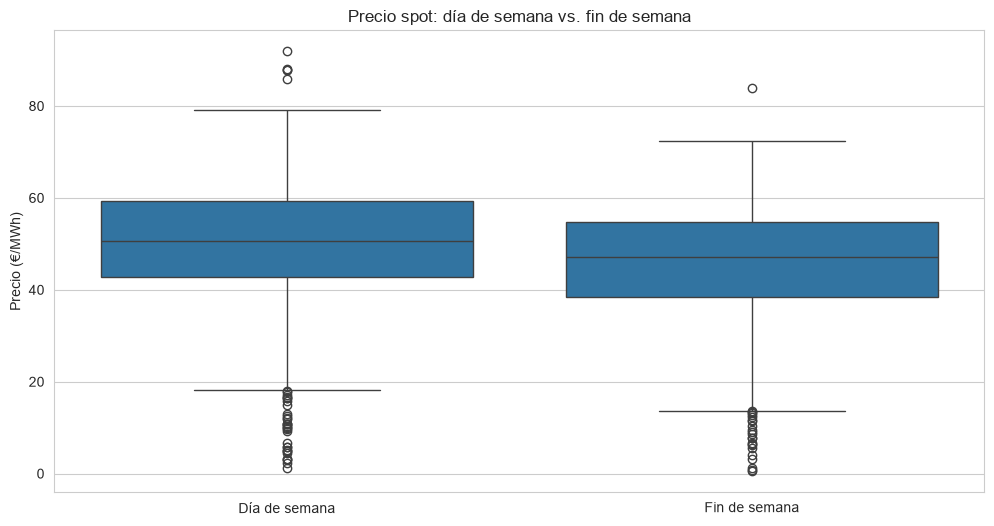

In [24]:
sns.boxplot(x='es_finde', y='precio_eur_mwh', data=serie_es)
plt.title('Precio spot: día de semana vs. fin de semana')
plt.xlabel('')
plt.ylabel('Precio (€/MWh)')
plt.xticks([0, 1], ['Día de semana', 'Fin de semana'])
plt.show()